In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.9.21
stan


# 1. Workbook setups

## 1.1 Import packages

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

## 1.2 Miscellaneous codes

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

## 1.3 Dictionaries

In [4]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [5]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = '/home/ronnie/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/stan_models/'

In [6]:
from cmdstanpy import CmdStanModel

test_model = CmdStanModel(stan_file=os.path.join(stan_models_path,"test_model.stan"), 
                          force_compile=True)
fit = test_model.sample(chains=1, iter_sampling=100, iter_warmup=100, seed=42)


13:36:36 - cmdstanpy - INFO - compiling stan file /home/ronnie/Documents/GitHub/culRI-Bayesian/stan_models/test_model.stan to exe file /home/ronnie/Documents/GitHub/culRI-Bayesian/stan_models/test_model
13:36:55 - cmdstanpy - INFO - compiled model executable: /home/ronnie/Documents/GitHub/culRI-Bayesian/stan_models/test_model
13:36:55 - cmdstanpy - INFO - CmdStan start processing
chain 1 |██████████| 00:00 Sampling completed


13:36:55 - cmdstanpy - INFO - CmdStan done processing.


# 2. Import data

## 2.1 Culture Compilation

In [7]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'compiled-regression-dataset.csv'
reg_data_full = pd.read_csv(os.path.join(fpath, fname)).drop(columns=['Unnamed: 0'])
reg_data_full = reg_data_full.rename(columns={'RI_zhang16_scaled':'scaledRI'})
reg_data_full = reg_data_full[reg_data_full['Source']!='Verma et al. (2024) Biogeosciences'].reset_index(drop=True)

sel_datatype = ['coretop','mesocosm']
sel_features = ['GTDB_order', 'NCBI_order','GTDB_family', 'NCBI_family']

for col in sel_features:
    for dt in sel_datatype:
        reg_data_full[reg_data_full.datatype==dt][col] = reg_data_full[reg_data_full.datatype==dt][col].fillna(dt,inplace=True)

    
reg_data_full['datatype2'] = ['culture-combined' if 'culture' in x else x for x in reg_data_full['datatype']]
reg_data_full['datatype3'] = [x if x in ['coretop'] else 'culture-mesocosm-combined' for x in reg_data_full['datatype']]
reg_data_full.replace([np.inf, -np.inf], np.nan, inplace=True)
reg_data_full['gdgt23ratio_binned'] = pd.cut(reg_data_full['gdgt23ratio'],bins=[0,5,200])
reg_data_full['modernWaterDepth']=reg_data_full['modernWaterDepth'].replace({np.nan:0,-999.:0}).astype(float)
reg_data_full['Ln_gdgt23ratio'] = np.log(reg_data_full['gdgt23ratio'])
reg_data_full['antiTEX86'] = reg_data_full['fGDGT_cren']/(reg_data_full['fGDGT_cren']+reg_data_full['fGDGT_0'])
reg_data_full['odd2even_ratio'] = (reg_data_full['fGDGT_0']+reg_data_full['fGDGT_2']+reg_data_full['fGDGT_cren']+reg_data_full['fGDGT_cren_prime'])/(reg_data_full['fGDGT_1']+reg_data_full['fGDGT_3'])
reg_data_full['organism_broadClass4'] = reg_data_full['organism_broadClass3']

for i in range(len(reg_data_full)):
    if reg_data_full['organism_broadClass4'][i] != 'Group 1.1a-Nitrosopumilus':
        continue
    else:
        reg_data_full['organism_broadClass4'][i] = 'Group 1.1a-Strain '+reg_data_full['Strains'][i]

temp_publication_year = []
for i in range(len(reg_data_full)):
    string = reg_data_full['Source'][i]
    if string == 'this study':
        temp_publication_year.append(2024)
    elif 'et al' in string:
        
        lookup_str = 'et al. ('
        start = string.find(lookup_str)+len(lookup_str)
        end = string.find(')',start)
        substring = string[start:end]
        try:
            temp_publication_year.append(int(substring))
        except:
            temp_publication_year.append(substring)
    else:
        substring = string[-4:]
        
        try:
            temp_publication_year.append(int(substring))
        except:
            temp_publication_year.append(2015)
        
        
reg_data_full['publication_year'] = np.array(temp_publication_year)
reg_data = reg_data_full[reg_data_full['experiment_setup'].isin(['coretop', 'mesocosm', 'culture-temperature'])].reset_index(drop=True)
reg_data

,sampleID,sampleName,Source,modernWaterDepth,Latitude,Longitude,SST,TEX86,RI_zhang16,RI_zhang16_revised,...,CPMPindex,Bp21index,datatype2,datatype3,gdgt23ratio_binned,Ln_gdgt23ratio,antiTEX86,odd2even_ratio,organism_broadClass4,publication_year
0,TEXAS_PSM_RR00002,KNR195-5 MC11,this study,2288.0,-1.5327,-86.7852,23.591499,0.602873,2.341606,2.874369,...,0.885404,0.024235,coretop,coretop,"(5, 200]",2.579114,0.601581,12.797594,coretop,2024
1,TEXAS_PSM_RR00005,KNR195-5 MC18,this study,1024.0,-3.969,-81.31,21.894609,0.599447,2.566525,3.158231,...,0.712414,0.060171,coretop,coretop,"(0, 5]",1.585700,0.665090,12.603740,coretop,2024
2,TEXAS_PSM_RR00007,KNR195-5 MC25,this study,381.0,-3.583,-81.165,22.924891,0.617192,2.503135,3.072126,...,0.774334,0.068899,coretop,coretop,"(0, 5]",1.483787,0.648727,11.765257,coretop,2024
3,TEXAS_PSM_RR00008,KNR195-5 MC33,this study,2949.0,-3.2237,-82.9142,21.708290,0.605147,2.427417,2.980611,...,0.767411,0.044077,coretop,coretop,"(5, 200]",1.926965,0.625099,11.850504,coretop,2024
4,TEXAS_PSM_RR00009,KNR195-5 MC34,this study,3224.0,-3.5975,-83.9632,22.364599,0.588670,2.248913,2.751584,...,0.816373,0.036781,coretop,coretop,"(5, 200]",2.131874,0.577592,10.864232,coretop,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2129,TEXAS_PSM_culture_nonThaum_RR049,Elling_etal_unpubl_Nitropelagicus brevis CN25_...,Elling et al. Unpublished,0.0,culture,culture,NaN,0.669428,2.033363,2.348056,...,0.535800,0.148406,culture-combined,culture-mesocosm-combined,"(0, 5]",0.555490,0.387553,2.468258,NaN,et al. Unpublishe
2130,TEXAS_PSM_culture_nonThaum_RR050,Elling_etal_unpubl_Cand. Nitrosomarinus catali...,Elling et al. Unpublished,0.0,culture,culture,NaN,0.290912,1.698968,2.089815,...,0.185628,0.116160,culture-combined,culture-mesocosm-combined,"(0, 5]",0.153050,0.431936,11.463714,Group 1.1a-Strain SPOT1,et al. Unpublishe
2131,TEXAS_PSM_culture_nonThaum_RR051,Elling_etal_unpubl_Cand. Nitrosomarinus catali...,Elling et al. Unpublished,0.0,culture,culture,NaN,0.379748,2.192347,2.716111,...,0.299999,0.103555,culture-combined,culture-mesocosm-combined,"(0, 5]",0.593672,0.559395,18.852115,Group 1.1a-Strain SPOT1,et al. Unpublishe
2132,TEXAS_PSM_culture_nonThaum_RR052,Elling_etal_unpubl_Cand. Nitrosomarinus catali...,Elling et al. Unpublished,0.0,culture,culture,NaN,0.372124,2.368373,2.923724,...,0.354855,0.072813,culture-combined,culture-mesocosm-combined,"(0, 5]",1.047487,0.616933,12.327048,Group 1.1a-Strain SPOT1,et al. Unpublishe


# Build the base model of RI vs temperature based on culture data

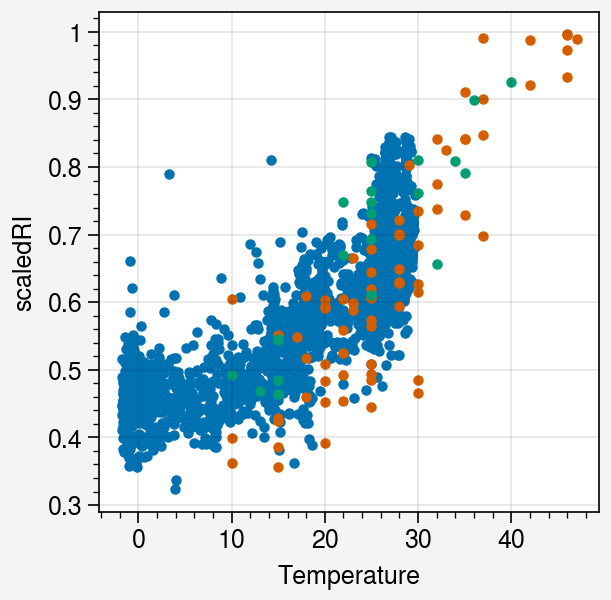

In [8]:
fig, axs = plot.subplots()

ax = axs[0]
plot_data = reg_data[reg_data['QC_flag']=='include'][reg_data['Temperature']<50]
grouped = plot_data.groupby('datatype2')
for name, group in grouped:
    plot_x = group['Temperature']
    plot_y = group['scaledRI']
    ax.scatter(plot_x, plot_y, label=name, s=10)

In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_df

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,GTDB_classGTDB_family
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,culture-temperature_Terrestrial thermophile,NaN
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,culture-temperature_Terrestrial thermophile,NaN
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,culture-temperature_Terrestrial thermophile,NaN
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,culture-temperature_Marine mesophile,NaN
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,culture-temperature_Marine mesophile,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.035219,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm
146,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.055801,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm
147,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.045612,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm
148,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.054250,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm


In [10]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_mesocosm_data = culture_meso_df[culture_meso_df['Temperature']<50]

x = culture_mesocosm_data['Temperature'].astype(float).tolist() 
y = culture_mesocosm_data['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_mesocosm_data),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"), compile=True)

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post = fit.stan_variable("x0")
k_post = fit.stan_variable("k")
b_post = fit.stan_variable("b")
sigma_post = fit.stan_variable("sigma")


13:36:56 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.
13:36:56 - cmdstanpy - INFO - Chain [1] start processing
13:36:56 - cmdstanpy - INFO - Chain [2] start processing
13:36:56 - cmdstanpy - INFO - Chain [3] start processing
13:36:56 - cmdstanpy - INFO - Chain [4] start processing


Chain [3] method = sample (Default)Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpy0q0cs1h/hzumqqn2.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain

13:36:56 - cmdstanpy - INFO - Chain [3] done processing


Chain [1] Iteration:  700 / 1500 [ 46%]  (Sampling)
Chain [4] Iteration:  600 / 1500 [ 40%]  (Sampling)
Chain [2] Iteration:  700 / 1500 [ 46%]  (Sampling)
Chain [3] Iteration:  900 / 1500 [ 60%]  (Sampling)
Chain [1] Iteration:  800 / 1500 [ 53%]  (Sampling)
Chain [2] Iteration:  800 / 1500 [ 53%]  (Sampling)
Chain [3] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [4] Iteration:  700 / 1500 [ 46%]  (Sampling)
Chain [1] Iteration:  900 / 1500 [ 60%]  (Sampling)
Chain [3] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [2] Iteration:  900 / 1500 [ 60%]  (Sampling)
Chain [4] Iteration:  800 / 1500 [ 53%]  (Sampling)
Chain [1] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [3] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [2] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [3] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [1] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration:  900 / 1500 [ 60%]  (Sampling)
Chain [2] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [3] It

13:36:56 - cmdstanpy - INFO - Chain [1] done processing
13:36:56 - cmdstanpy - INFO - Chain [2] done processing
13:36:56 - cmdstanpy - INFO - Chain [4] done processing
13:36:56 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'logistic_fixed_asymptote.stan', line 20, column 2 to column 61)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'logistic_fixed_asymptote.stan', line 20, column 2 to column 61)


Chain [4] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [1] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [2] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [1] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [4] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [2] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0.157 seconds (Warm-up)
Chain [1] 0.346 seconds (Sampling)
Chain [1] 0.503 seconds (Total)
Chain [1] 
Chain [1] 
Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0.149 seconds (Warm-up)
Chain [2] 0.348 seconds (Sampling)
Chain [2] 0.497 seconds (Total)
Chain [2] 
Chain [2] 
Chain [4] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [4] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0.147 seconds (Warm-up)
Chain [4] 0.414 secon

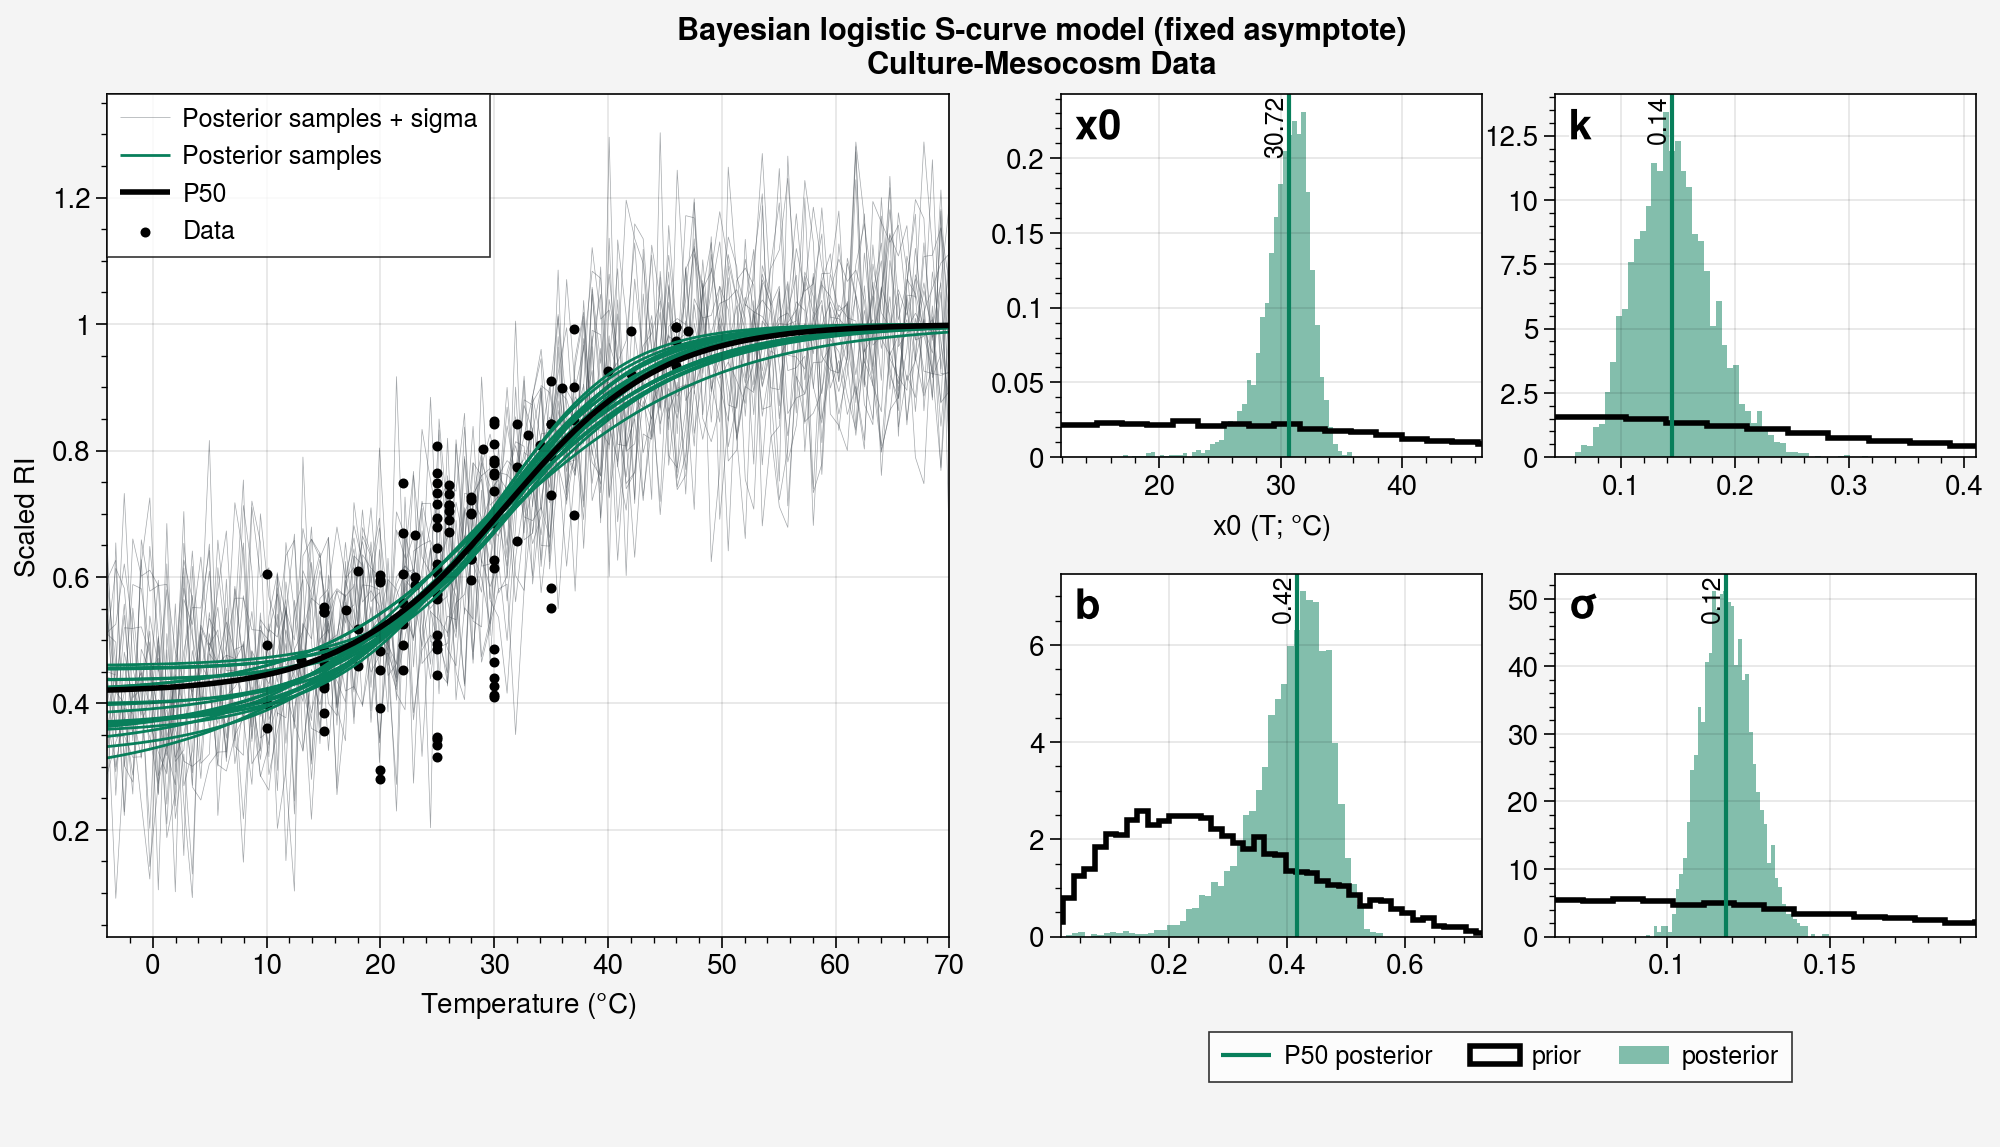

In [12]:
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,70, 100)
RI_pred_culture_meco_samples = []
RI_pred_culture_meco_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post))
        x0 = x0_post[i]
        k = k_post[i]
        b = b_post[i]
        sigma = sigma_post[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_meco_samples.append(y_pred)
        RI_pred_culture_meco_noisy_samples.append(y_pred_noisy)
RI_pred_culture_meco_samples = np.array(RI_pred_culture_meco_samples)
RI_p50 = np.percentile(RI_pred_culture_meco_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_culture_meco_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_culture_meco_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        ax.plot(x_sample, RI_pred_culture_meco_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meco_samples))
        ax.plot(x_sample, RI_pred_culture_meco_samples[rand_idx], color="teal9", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="teal9", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_post, bins=50, color='teal9', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_post,50)
ax.axvline(p50_x0, color='teal9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_post, bins=50, color='teal9', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_post,50)
ax.axvline(p50_k, color='teal9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_post, bins=50, color='teal9', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_post,50)
ax.axvline(p50_b, color='teal9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post, bins=50, color='teal9', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_post,50)
ax.axvline(p50_sigma, color='teal9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_post,k_post,b_post,sigma_post]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.7,np.max(params[i-1])*1.3])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

In [ ]:
# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_2STD = np.mean(x0_post), np.std(x0_post)*2
K_MEAN, K_2STD = np.mean(k_post), np.std(k_post)*2
B_MEAN, B_2STD = np.mean(b_post), np.std(b_post)*2

# Define Stan data dictionary
coretop_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "X0_MEAN": X0_MEAN,
    "X0_2STD": X0_2STD,
    "K_MEAN": K_MEAN,
    "K_2STD": K_2STD,
    "B_MEAN": B_MEAN,
    "B_2STD": B_2STD
}

# Compile and sample from the core-top model
coretop_model = CmdStanModel(stan_file=os.path.join(stan_models_path, 
                                                    "coretop_regression_post_stats.stan"))

coretop_fit = coretop_model.sample(data=coretop_stan_data, 
                                   chains=4, 
                                   iter_warmup=500, 
                                   iter_sampling=1000, 
                                   parallel_chains=4,
                                   show_console=True,
                                   seed=42)

# Check available variables before extracting
print("Available variables:", coretop_fit.stan_variables().keys())

# Extract posterior samples 
x0_coretop_post_stats = coretop_fit.stan_variable("x0")
k_coretop_post_stats = coretop_fit.stan_variable("k")
b_coretop_post_stats = coretop_fit.stan_variable("b")
sigma_coretop_post_stats = coretop_fit.stan_variable("sigma")

<a list of 1 Line2D objects>

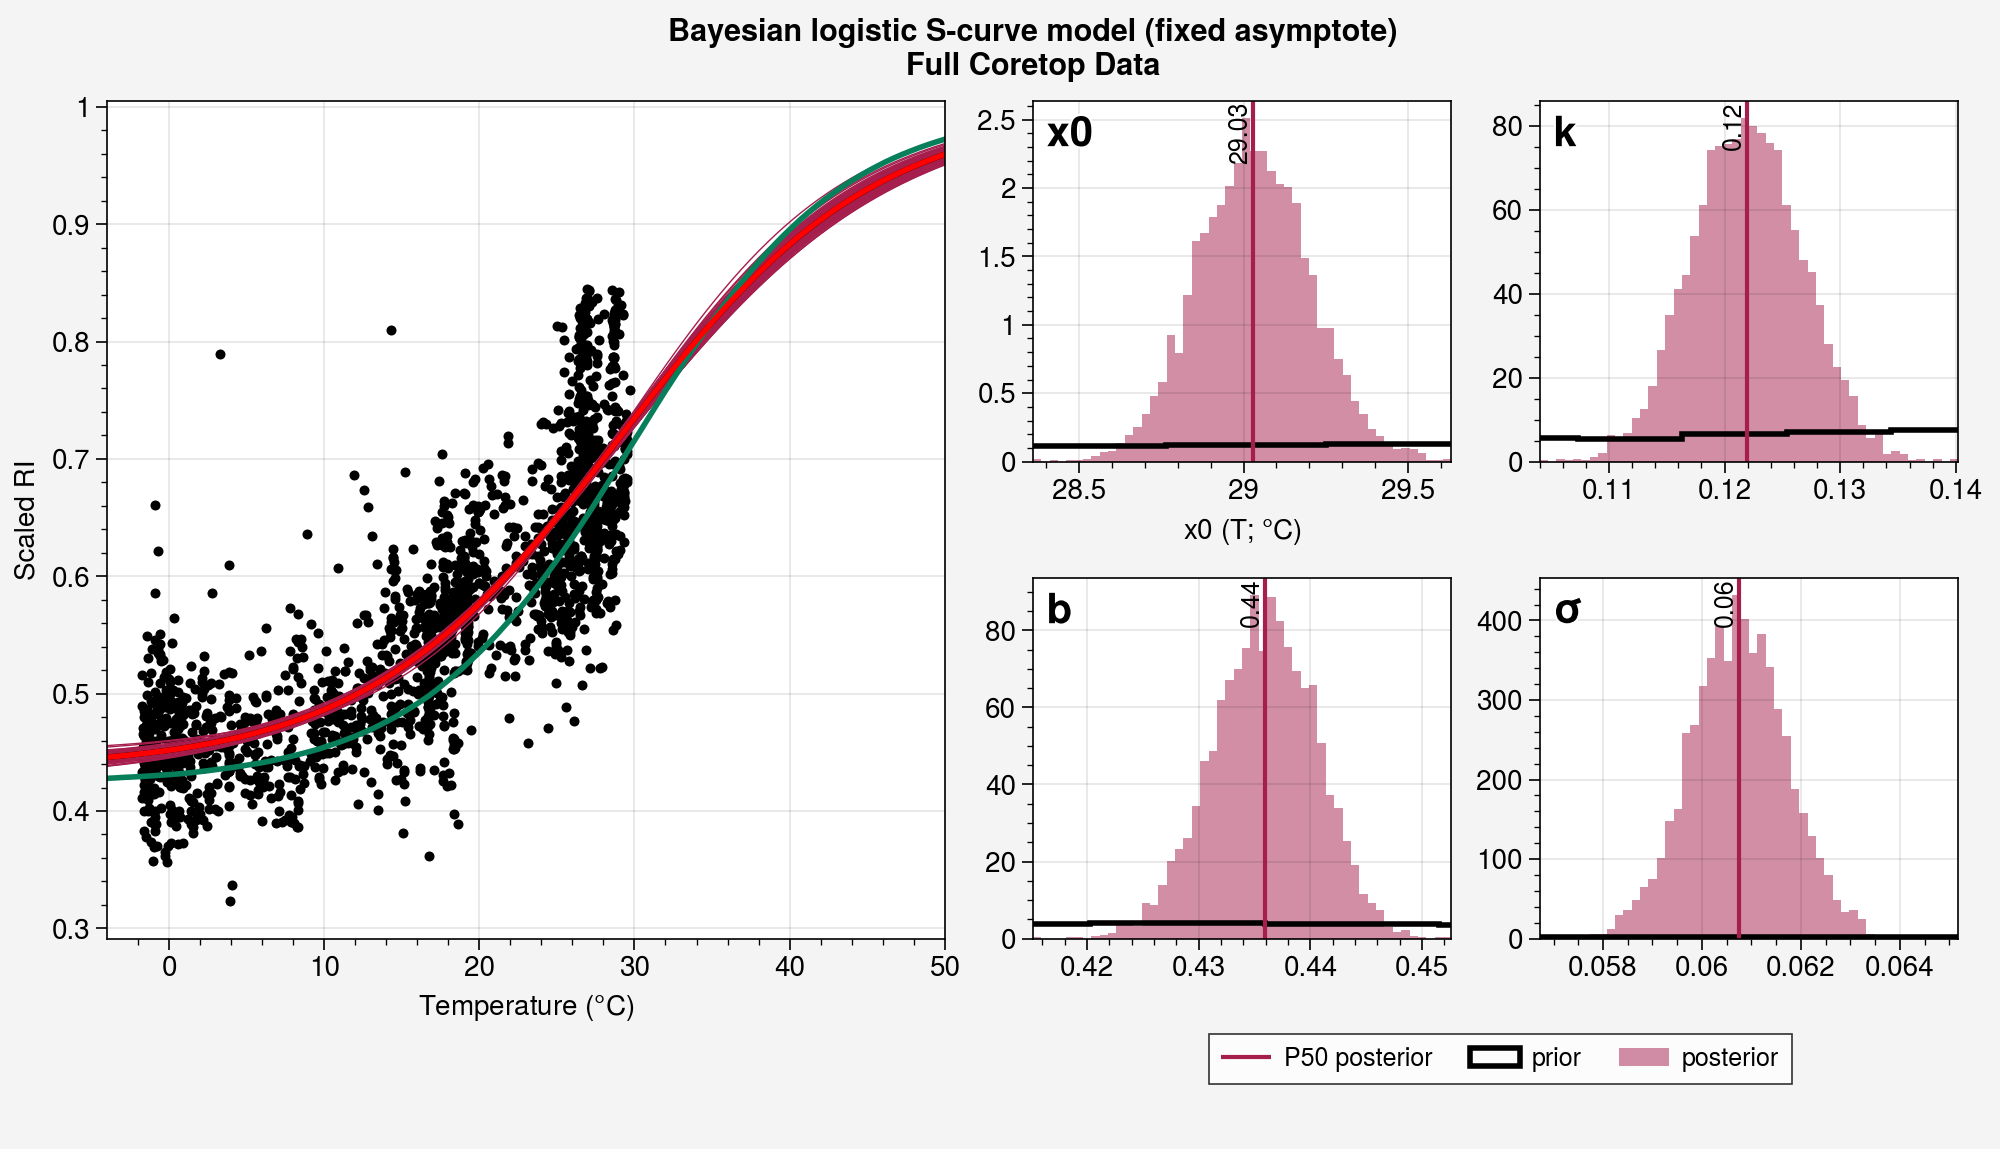

In [ ]:
# Compute posterior means and standard deviations
X0_MEAN, X0_2STD = np.mean(x0_post), np.std(x0_post)*2
K_MEAN, K_2STD = np.mean(k_post), np.std(k_post)*2
B_MEAN, B_2STD = np.mean(b_post), np.std(b_post)*2

X0_MEDIAN = np.median(x0_post)
K_MEDIAN = np.median(k_post)
B_MEDIAN = np.median(b_post)

###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_coretop_full_post_stats_samples = []
RI_pred_coretop_full_post_stats_noisy_samples = []
for i in range(4000):
        x0 = x0_coretop_post_stats[i]
        k = k_coretop_post_stats[i]
        b = b_coretop_post_stats[i]
        sigma = sigma_coretop_post_stats[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_coretop_full_post_stats_samples.append(y_pred)
        RI_pred_coretop_full_post_stats_noisy_samples.append(y_pred_noisy)
RI_pred_coretop_full_post_stats_samples = np.array(RI_pred_coretop_full_post_stats_samples)
RI_p50 = np.percentile(RI_pred_coretop_full_post_stats_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_coretop_full_post_stats_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_coretop_full_post_stats_samples, 95, axis=0)
RI_p0 = np.percentile(RI_pred_coretop_full_post_stats_samples, 0, axis=0)
RI_p100 = np.percentile(RI_pred_coretop_full_post_stats_samples, 100, axis=0)
RI_p5_noisy = np.percentile(RI_pred_coretop_full_post_stats_noisy_samples, 5, axis=0)
RI_p95_noisy = np.percentile(RI_pred_coretop_full_post_stats_noisy_samples, 95, axis=0)
# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
# ## plot random 10 samples from y_pred_noisy
# for i in range(20):
#         rand_idx = np.random.randint(0, len(RI_pred_coretop_full_post_stats_noisy_samples))
#         ax.plot(x_sample, RI_pred_coretop_full_post_stats_noisy_samples[rand_idx], color="gray7", lw=0.5,alpha=0.5)
## plot random 100 samples frpm y_pred
for i in range(100):
        rand_idx = np.random.randint(0, len(RI_pred_coretop_full_post_stats_samples))
        ax.plot(x_sample, RI_pred_coretop_full_post_stats_samples[rand_idx], color="pink9", lw=0.5)
ax.scatter(x_coretop, y_coretop, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5_noisy, RI_p95_noisy, color="pink9", alpha=0.75, label="P5-P95")

### plot p50 of the first layer
ax.plot(x_sample,np.percentile(RI_pred_culture_meco_samples, 50, axis=0),c='teal9',lw=2)

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x0 as normal(X0_MEAN,X0_STD)
x0_prior = np.random.normal(X0_MEAN, X0_2STD, 10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_coretop_post_stats,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(K_MEAN,K_3STD)
k_prior = np.random.normal(K_MEAN, K_2STD, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_coretop_post_stats,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as normal(B_MEAN, B_3STD)
b_prior = np.random.normal(B_MEAN, B_2STD, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_coretop_post_stats,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.5   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_coretop_post_stats,50)
ax.axvline(p50_sigma, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_coretop_post_stats,k_coretop_post_stats,b_coretop_post_stats,sigma_coretop_post_stats]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1]),np.max(params[i-1])])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nFull Coretop Data',
           titleweight='bold',titlesize=15,
           fontsize=10)


#### plot a curve based on p50_x0, p50_k, p50_b, p50_sigma
y_pred = ((1-p50_b) / (1 + np.exp(-p50_k * (x_sample - p50_x0)))) + p50_b

axs[0].plot(x_sample, y_pred, color="red", lw=2, label="P50 posterior")



In [ ]:
coretop_df.columns

NameError: name 'coretop_df' is not defined

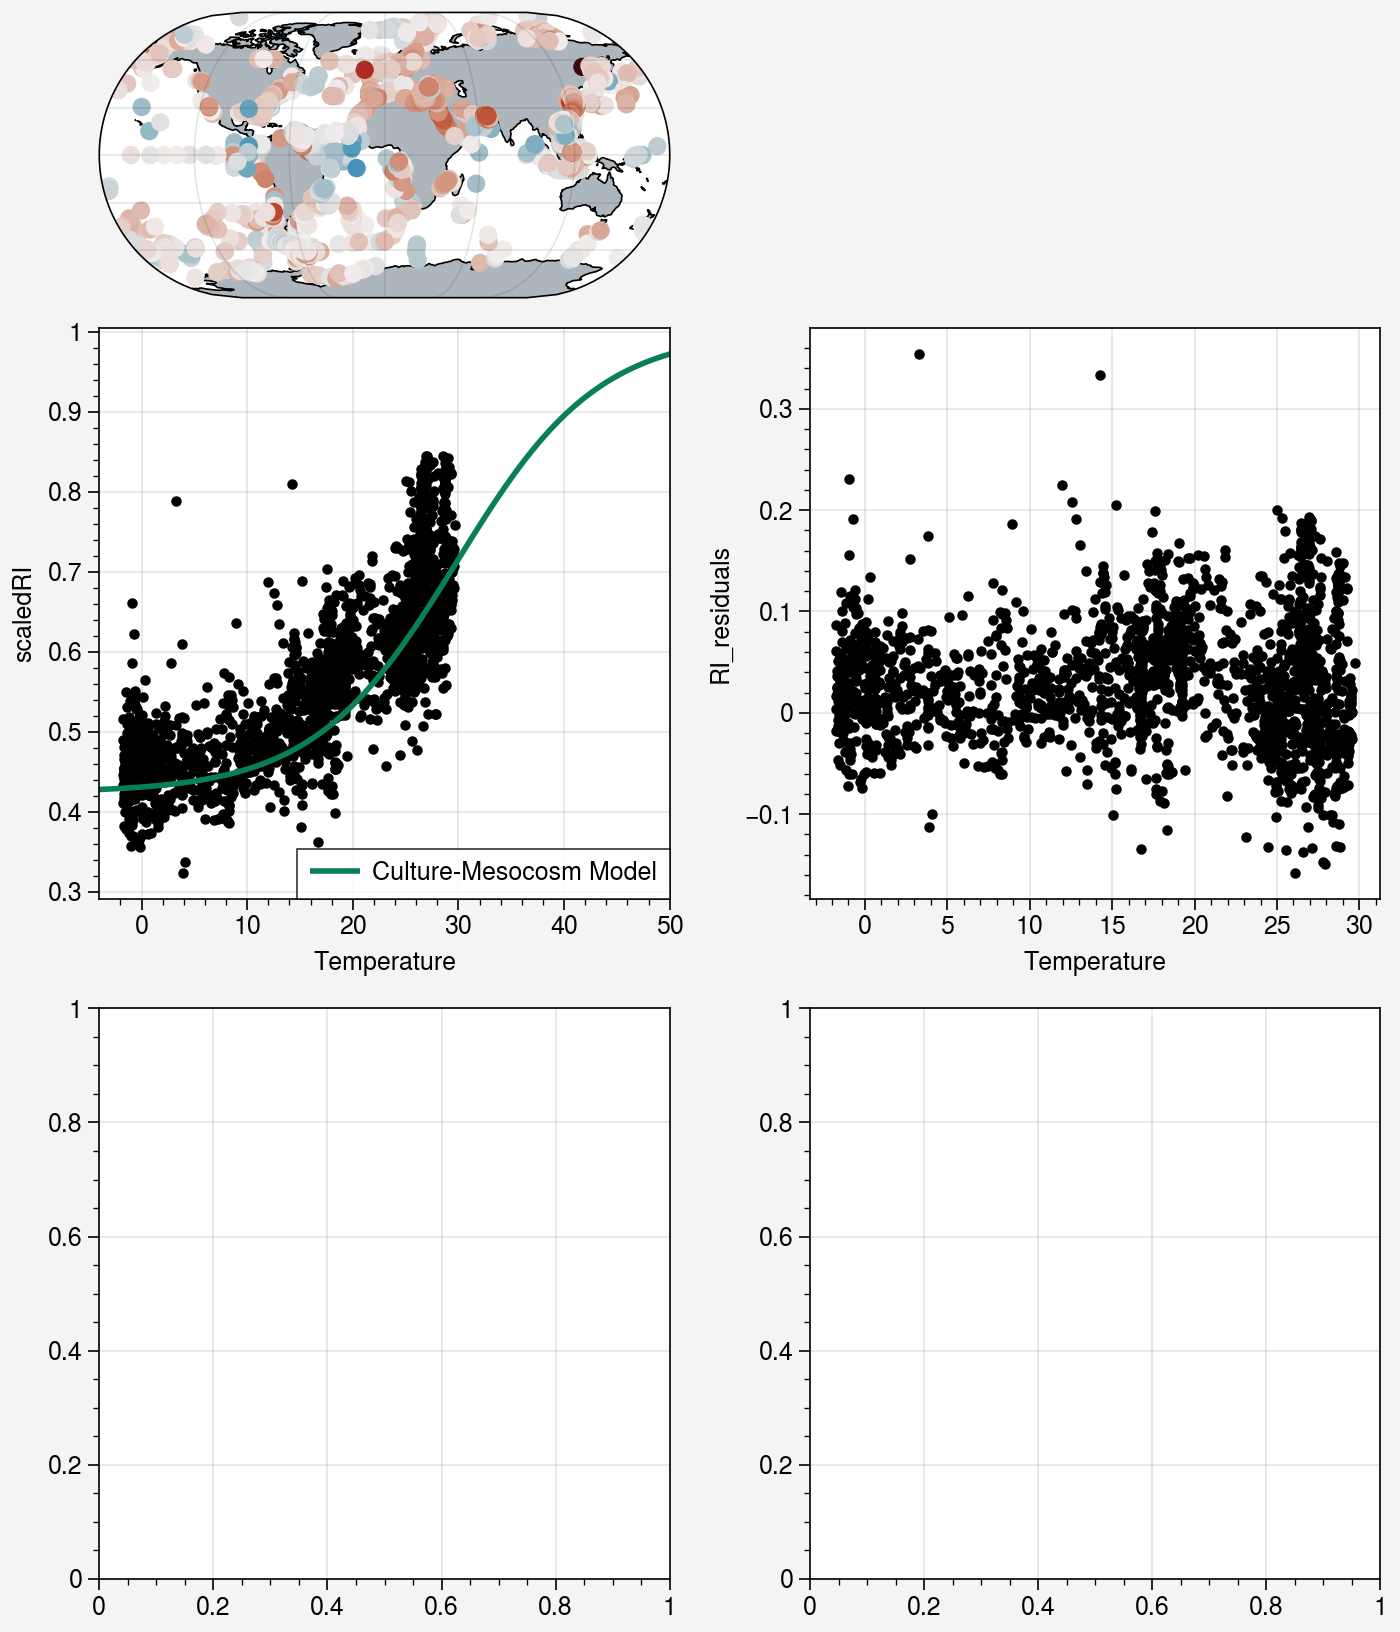

In [ ]:
### calculate RI_residuals from the p50 of the posterior samples
coretop_df = reg_data[reg_data['datatype']=='coretop'].copy()
coretop_df['Latitude'] = coretop_df['Latitude'].astype(float)
coretop_df['Longitude'] = coretop_df['Longitude'].astype(float)
def get_pred_RI_culture_meso(temp):
    return ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (temp - X0_MEDIAN)))) + B_MEDIAN
coretop_df['pred_RI_culture_meso'] = coretop_data['Temperature'].apply(get_pred_RI_culture_meso)
coretop_df['RI_residuals'] = coretop_df['scaledRI'] - coretop_df['pred_RI_culture_meso']


plot_data = coretop_df[coretop_df['gdgt23ratio']<50].dropna(subset=['RI_residuals'])

array = [
    [1,0],
    [2,3],
    [4,5]
]
fig, axs = plot.subplots(array,proj=('eck3',None),width=7,
                         hratios=(0.5,1,1),
                         share=0)
axs.format(
    land=True,landcolor='gray5',landzorder=0,
    coast=True,coastzorder=0,
)

ax = axs[0]
plot_lon = plot_data['Longitude']
plot_lat = plot_data['Latitude']
plot_RI_residuals = plot_data['RI_residuals']
ax.scatter(plot_lon, plot_lat,c=plot_RI_residuals,cmap='balance')

ax = axs[1]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
plot_c = plot_data['gdgt23ratio']
m = ax.scatter(plot_x, plot_y, c='k', cmap='matter', label=name, s=10)
# ax.colorbar(m, label='GDGT-2/3 ratio',loc='ul')
x_sample = np.linspace(-4,50, 100)
y_pred = ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (x_sample - X0_MEDIAN)))) + B_MEDIAN
ax.plot(x_sample, y_pred, color="teal9", lw=2, label="Culture-Mesocosm Model")
h, l = ax.get_legend_handles_labels()
ax.legend(h, ['Culture-Mesocosm Model'], loc='lr', fontsize=8,ncols=3,)
### plot previously published calibration curves


ax = axs[2] # plot RI_residuals vs temperature
plot_x = plot_data['Temperature']
plot_y = plot_data['RI_residuals']
ax.scatter(plot_x, plot_y, c='k', s=10)


In [ ]:
import numpy as np
import os
from cmdstanpy import CmdStanModel

# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Define Stan data dictionary (Pass full posteriors)
coretop_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "M": len(x0_post),  # Use all posterior draws
    "x0_post": x0_post.tolist(),
    "k_post": k_post.tolist(),
    "b_post": b_post.tolist()
}

# Compile and sample from the core-top model
coretop_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_regression_kde_inside.stan"))

coretop_full_posterior_fit = coretop_model.sample(
    data=coretop_stan_data,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    parallel_chains=4,
    seed=42
)

# Extract posterior samples from second-layer model
x0_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("x0")
k_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("k")
b_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("b")
sigma_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("sigma")


09:36:21 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_kde_inside.stan to exe file /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_kde_inside
09:36:29 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_kde_inside
09:36:29 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█▊        | 00:00 Iteration:  100 / 1500 [  6%]  (Warmup)


chain 1 |██▉       | 00:00 Iteration:  300 / 1500 [ 20%]  (Warmup)



chain 1 |████▋     | 00:00 Iteration:  501 / 1500 [ 33%]  (Sampling)


chain 1 |█████▉    | 00:00 Iteration:  700 / 1500 [ 46%]  (Sampling)


chain 1 |███████   | 00:00 Iteration:  900 / 1500 [ 60%]  (Sampling)


chain 1 |████████▏ | 00:00 Iteration: 1100 / 1500 [ 73%]  (Sampling)


chain 1 |█████████▍| 00:01 Iteration: 1300 / 1500 [ 86%]  (Sampling)

chain 1 |███████


09:36:30 - cmdstanpy - INFO - CmdStan done processing.
09:36:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
Consider re-running wi

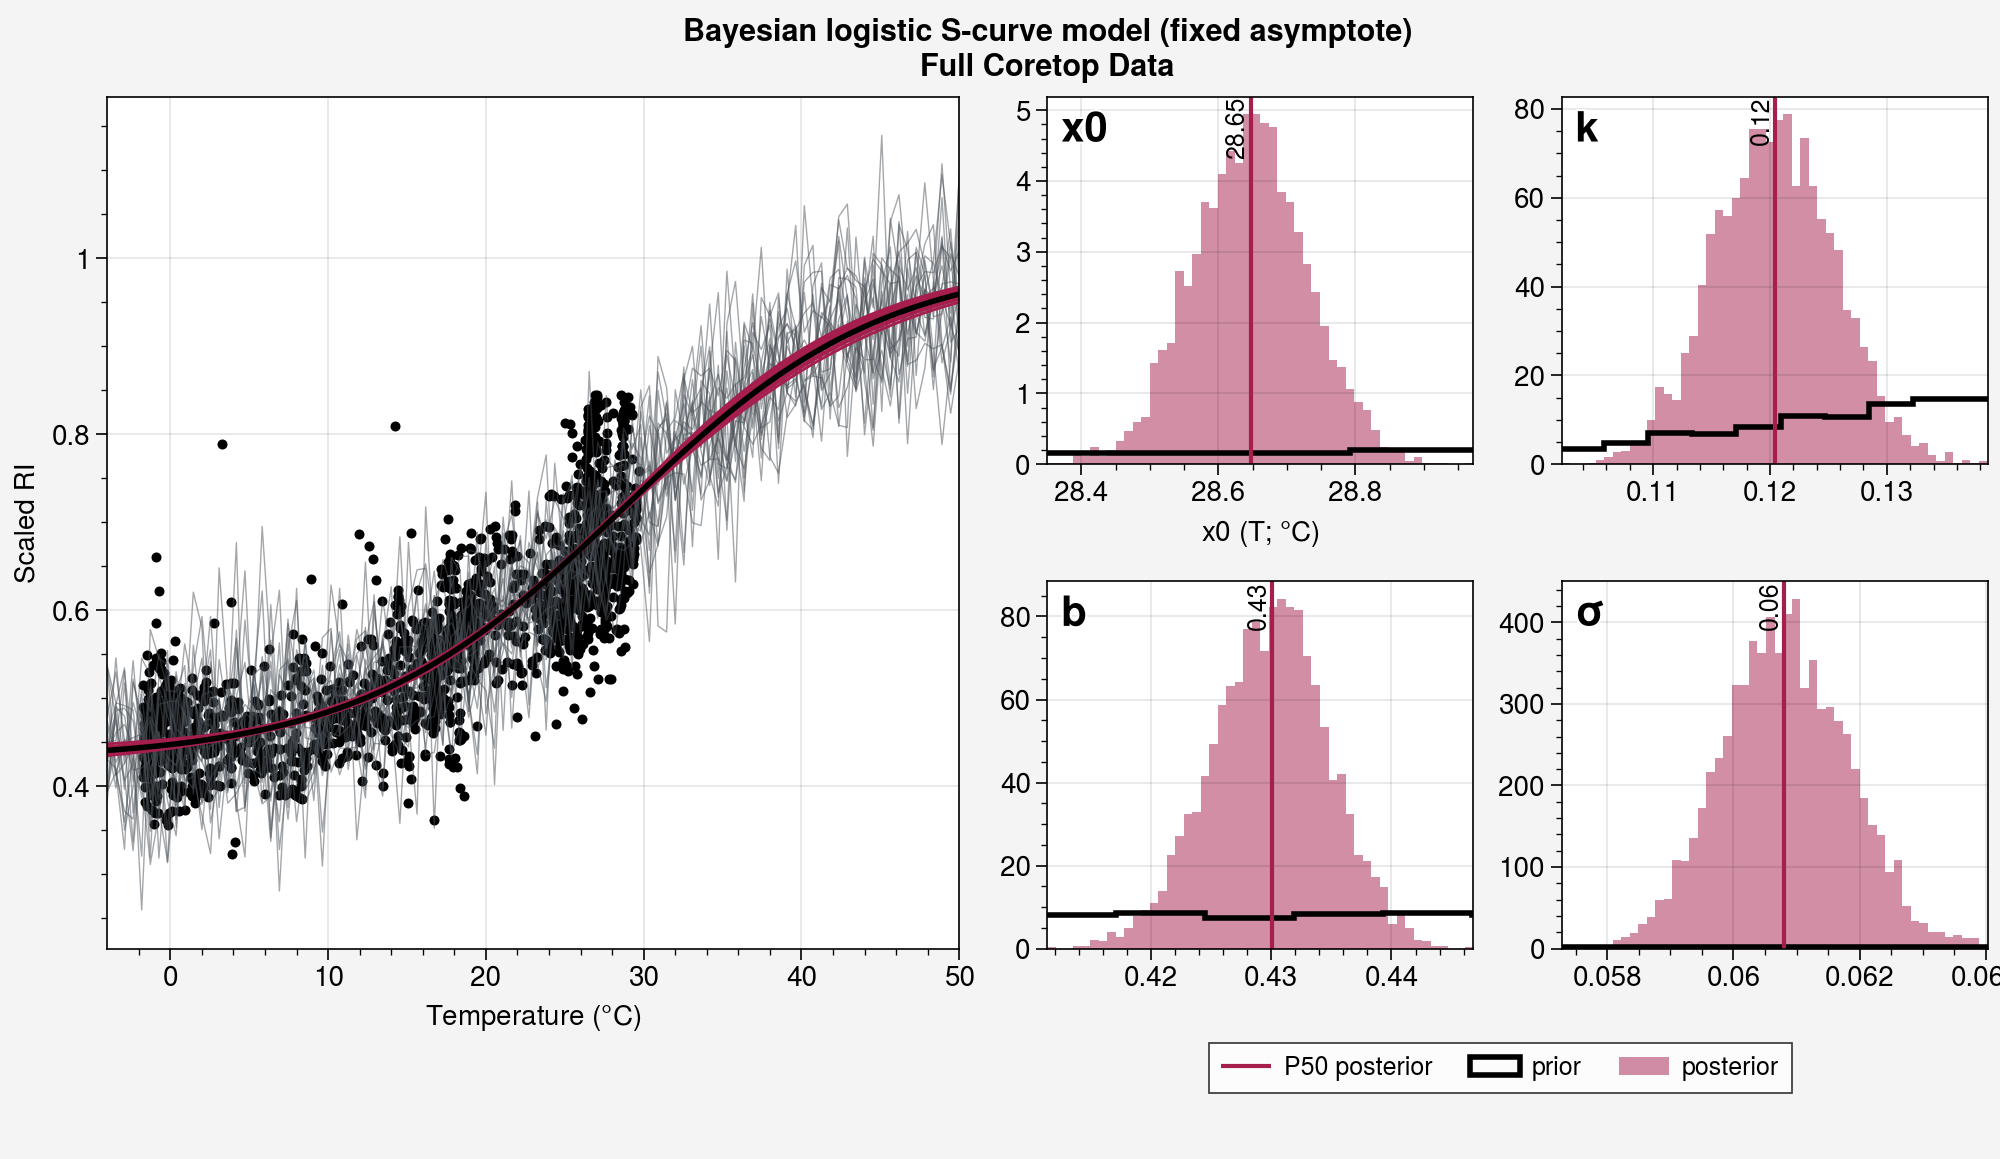

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, gaussian_kde

# Fix the random seed for reproducibility
np.random.seed(42)

# Generate x-values for predictions
x_sample = np.linspace(-4, 50, 100)

# Compute predicted y by randomly sampling from the second-layer posterior
RI_pred_coretop_full_samples = []
RI_pred_coretop_full_noisy_samples = []

for i in range(4000):  
    x0 = x0_coretop_full_posterior[i]
    k = k_coretop_full_posterior[i]
    b = b_coretop_full_posterior[i]
    sigma = sigma_coretop_full_posterior[i]

    # Compute predicted y using logistic function
    y_pred = ((1 - b) / (1 + np.exp(-k * (x_sample - x0)))) + b
    y_pred_noisy = np.random.normal(y_pred, sigma)

    # Store predictions
    RI_pred_coretop_full_samples.append(y_pred)
    RI_pred_coretop_full_noisy_samples.append(y_pred_noisy)

# Convert to NumPy arrays
RI_pred_coretop_full_samples = np.array(RI_pred_coretop_full_samples)
RI_p50 = np.percentile(RI_pred_coretop_full_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_coretop_full_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_coretop_full_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)

# === PLOT 1: Predictions & Observations ===
ax = axs[0]

# Plot random 20 samples from y_pred_noisy
for i in range(20):
    rand_idx = np.random.randint(0, len(RI_pred_coretop_full_noisy_samples))
    ax.plot(x_sample, RI_pred_coretop_full_noisy_samples[rand_idx], color="gray7", lw=0.5, alpha=0.5)

# Plot random 20 samples from y_pred
for i in range(20):
    rand_idx = np.random.randint(0, len(RI_pred_coretop_full_samples))
    ax.plot(x_sample, RI_pred_coretop_full_samples[rand_idx], color="pink9", lw=1)

ax.scatter(x_coretop, y_coretop, label="Data", color="black", marker='.')
ax.plot(x_sample, RI_p50, color="k", label="P50", lw=2)
ax.fill_between(x_sample, RI_p5, RI_p95, color="pink9", alpha=0.2, label="P5-P95")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Scaled RI")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x0 as normal(X0_MEAN,X0_STD)
x0_prior = x0_post
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_coretop_full_posterior,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as k_post from the first layer
k_prior = k_post
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_coretop_full_posterior,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as normal(B_MEAN, B_3STD)
b_prior = b_post
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_coretop_full_posterior,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]

### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.5   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_coretop_full_posterior,50)
ax.axvline(p50_sigma, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_coretop_full_posterior,k_coretop_full_posterior,b_coretop_full_posterior,sigma_coretop_full_posterior]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1]),np.max(params[i-1])])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nFull Coretop Data',
           titleweight='bold',titlesize=15,
           fontsize=10)


In [ ]:
# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI','gdgt23ratio'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
x2_coretop = coretop_data['gdgt23ratio'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_STD = np.mean(x0_post), np.std(x0_post)
K_MEAN, K_STD = np.mean(k_post), np.std(k_post)
B_MEAN, B_STD = np.mean(b_post), np.std(b_post)

# Define Stan data dictionary
coretop_combined_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "x2": x2_coretop,
    "X0_MEAN": X0_MEAN,
    "X0_STD": X0_STD,
    "K_MEAN": K_MEAN,
    "K_STD": K_STD,
    "B_MEAN": B_MEAN,
    "B_STD": B_STD
}

# Compile and sample from the core-top model
coretop_combined_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_combined.stan"))

coretop_combined_fit = coretop_combined_model.sample(data=coretop_combined_stan_data, chains=4, iter_warmup=500, iter_sampling=1000, seed=42)

# Check available variables before extracting
print("Available variables:", coretop_fit.stan_variables().keys())

# Extract posterior samples
coretop_combined_x0_post = coretop_combined_fit.stan_variable("x0")
coretop_combined_k_post = coretop_combined_fit.stan_variable("k")
coretop_combined_b_post = coretop_combined_fit.stan_variable("b")
coretop_combined_beta_x2_post = coretop_combined_fit.stan_variable("beta_x2")
coretop_combined_alpha_post = coretop_combined_fit.stan_variable("alpha")

09:36:31 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status






chain 1 |█▊        | 00:01 Iteration:  100 / 1500 [  6%]  (Warmup)



chain 1 |██▎       | 00:03 Iteration:  200 / 1500 [ 13%]  (Warmup)


chain 1 |██▉       | 00:03 Iteration:  300 / 1500 [ 20%]  (Warmup)




chain 1 |███▌      | 00:04 Iteration:  400 / 1500 [ 26%]  (Warmup)
chain 1 |████▋     | 00:05 Iteration:  501 / 1500 [ 33%]  (Sampling)


chain 1 |█████▎    | 00:06 Iteration:  600 / 1500 [ 40%]  (Sampling)


chain 1 |█████▉    | 00:07 Iteration:  700 / 1500 [ 46%]  (Sampling)


chain 1 |██████▍   | 00:08 Iteration:  800 / 1500 [ 53%]  (Sampling)


chain 1 |███████   | 00:09 Iteration:  900 / 1500 [ 60%]  (Sampling)


chain 1 |███████▋  | 00:10 Iteration: 1000 / 1500 [ 66%]  (Sampling)


chain 1 |████████▏ | 00:11 Iteration: 1100 / 1500 [ 73%]  (Sampling)



chain 1 |████████▊ | 00:12 Iteration: 1200 / 1500 [ 80%]  (Sampling)


chain 1 |██████████| 00:14 Sampling completed              


09:36:45 - cmdstanpy - INFO - CmdStan done processing.
09:36:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_combined.stan', line 34, column 2 to column 86)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_combined.stan', line 34, column 2 to column 86)
Consider re-running with show_console=True if the above output is unclear!



Available variables: dict_keys(['x0', 'k', 'b', 'sigma'])


In [ ]:
# Prepare core-top data
coretop_shallowAOA_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop') &
    (reg_data['gdgt23ratio'] < 5)
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop_shallowAOA = coretop_shallowAOA_data['Temperature'].astype(float).tolist()
y_coretop_shallowAOA = coretop_shallowAOA_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_STD = np.mean(x0_post), np.std(x0_post)
K_MEAN, K_STD = np.mean(k_post), np.std(k_post)
B_MEAN, B_STD = np.mean(b_post), np.std(b_post)

# Define Stan data dictionary
coretop_shallowAOA_stan_data = {
    "N": len(coretop_shallowAOA_data),
    "x": x_coretop_shallowAOA,
    "y": y_coretop_shallowAOA,
    "X0_MEAN": X0_MEAN,
    "X0_STD": X0_STD,
    "K_MEAN": K_MEAN,
    "K_STD": K_STD,
    "B_MEAN": B_MEAN,
    "B_STD": B_STD
}

# Compile and sample from the core-top model
coretop_shallowAOA_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_regression_fullpost.stan"))

coretop_shallowAOA_fit = coretop_shallowAOA_model.sample(data=coretop_shallowAOA_stan_data, chains=4, iter_warmup=500, iter_sampling=1000, seed=42)

# Check available variables before extracting
print("Available variables:", coretop_shallowAOA_fit.stan_variables().keys())

# Extract posterior samples
coretop_shallowAOA_x0_post = coretop_shallowAOA_fit.stan_variable("x0")
coretop_shallowAOA_k_post = coretop_shallowAOA_fit.stan_variable("k")
coretop_shallowAOA_b_post = coretop_shallowAOA_fit.stan_variable("b")


coretop_shallow_AOA_pred_samples = []


ValueError: no such file /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_fullpost.stan

In [ ]:
### plot coretop data
fig, axs = plot.subplots(ncols=4,share=0)
ax = axs[0]
ax.scatter(x_coretop, y_coretop, label="Data",m='.',mew=0, color="black")
x_sample = np.linspace(coretop_data['Temperature'].min(), 50, 100)
y_sample_P50 = (1-np.percentile(coretop_b_post,50)) / (1 + np.exp(-np.percentile(coretop_k_post,50) * (x_sample - np.percentile(coretop_x0_post,50))))  + np.percentile(coretop_b_post,50)

### plot posterior samples
for i in range(100):
    y_sample = (1-coretop_b_post[i]) / (1 + np.exp(-coretop_k_post[i] * (x_sample - coretop_x0_post[i])))  + coretop_b_post[i]
    ax.plot(x_sample, y_sample, color='pink5', lw=0.1)

### plot #P50 of the posterior samples
ax.plot(x_sample, y_sample_P50, color='pink9', label="P50", lw=2)

## plot posterior samples as histogram
ax = axs[1]
hist_ = ax.hist(coretop_x0_post, bins=50, color='pink9', alpha=0.5, label="x0")
p50_x0 = np.percentile(coretop_x0_post,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
ax.hist(coretop_k_post, bins=50, color='pink9', alpha=0.5, label="k")
p50_k = np.percentile(coretop_k_post,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90,)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
ax.hist(coretop_b_post, bins=50, color='pink9', alpha=0.5, label="b")
p50_b = np.percentile(coretop_b_post,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")


In [ ]:
### plot culture+mesocosm data and coretop data together
x_sample = np.linspace(-5,50, 100)

fig, axs = plot.subplots(ncols=4,nrows=3,share=0)
axs.format(
    rowlabels=['Culture+Mesocosm','Coretop','Comparison'],
)

ax = axs[0,0]
plot_data = culture_mesocosm_data
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='culture+mesocosm', m='.', mew=0, color='black')
### plot posterior fit
x0_cul_meso_P50 = np.percentile(x0_post,50)
k_cul_meso_P50 = np.percentile(k_post,50)
b_cul_meso_P50 = np.percentile(b_post,50)
y_sample_P50 = (1-b_cul_meso_P50) / (1 + np.exp(-k_cul_meso_P50 * (x_sample - x0_cul_meso_P50)))  + b_cul_meso_P50
ax.plot(x_sample, y_sample_P50, color='teal9', label="P50", lw=2)

ax = axs[1,0]
plot_data = coretop_data[coretop_data['gdgt23ratio']<5]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='coretop', m='.', mew=0, color='black')
plot_data = coretop_data[coretop_data['gdgt23ratio']>5]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='coretop', m='o', facecolor='none', mec='gray')
### plot posterior fit
x0_coretop_P50 = np.percentile(coretop_x0_post,50)
k_coretop_P50 = np.percentile(coretop_k_post,50)
b_coretop_P50 = np.percentile(coretop_b_post,50)
y_coretop_sample_P50 = (1-b_coretop_P50) / (1 + np.exp(-k_coretop_P50 * (x_sample - x0_coretop_P50)))  + b_coretop_P50
ax.plot(x_sample, y_coretop_sample_P50, color='pink9', label="P50", lw=2)

####################################################################################
### plot posterior fit
x0_coretop_combined_P50 = np.percentile(coretop_combined_x0_post,50)
k_coretop_combined_P50 = np.percentile(coretop_combined_k_post,50)
b_coretop_combined_P50 = np.percentile(coretop_combined_b_post,50)
beta_x2_coretop_combined_P50 = np.percentile(coretop_combined_beta_x2_post,50)
y_coretop_combined_sample_P50 = ((1-b_coretop_combined_P50) / (1 + np.exp(-k_coretop_combined_P50 * (x_sample - x0_coretop_combined_P50)))  + b_coretop_combined_P50) +5
ax.plot(x_sample, y_coretop_combined_sample_P50, color='yellow9', label="P50", lw=2)

####################################################################################
### plot posterior fit of shallow AOA coretop data
x0_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_x0_post,50)
k_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_k_post,50)
b_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_b_post,50)
y_coretop_shallowAOA_sample_P50 = (1-b_coretop_shallowAOA_P50) / (1 + np.exp(-k_coretop_shallowAOA_P50 * (x_sample - x0_coretop_shallowAOA_P50)))  + b_coretop_shallowAOA_P50
ax.plot(x_sample, y_coretop_shallowAOA_sample_P50, color='pink9', label="P50", lw=2, ls='--')

### plot posterior comparisons on last row
ax = axs[2,0]
ax.plot(x_sample, y_sample_P50, color='teal9', label="culture+mesocosm", lw=2)
ax.plot(x_sample, y_coretop_sample_P50, color='pink9', label="coretop", lw=2)
ax.plot(x_sample, y_coretop_shallowAOA_sample_P50, color='pink9', label="P50", lw=2, ls='--')

### plot histograms of x0, k, and b
culture_mesocosm_posteriors = [x0_post, k_post, b_post]
coretop_posteriors = [coretop_x0_post, coretop_k_post, coretop_b_post]
posterior_labels = ['x0','k','b']
for i in range(3):
    ax = axs[0,i+1]
    ax.hist(culture_mesocosm_posteriors[i], bins=50, color='teal9', alpha=0.5, label="culture+mesocosm")
    p50 = np.percentile(culture_mesocosm_posteriors[i],50)
    ax.axvline(p50, color='teal9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

    ax = axs[1,i+1]
    ax.hist(coretop_posteriors[i], bins=50, color='pink9', alpha=0.5, label="coretop")
    p50 = np.percentile(coretop_posteriors[i],50)
    ax.axvline(p50, color='pink9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50*0.99, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

    ax = axs[2,i+1]
    ax.hist(culture_mesocosm_posteriors[i], bins=50, color='teal9', alpha=0.5, label="culture+mesocosm")
    ax.hist(coretop_posteriors[i], bins=50, color='pink9', alpha=0.5, label="coretop")
    p50 = np.percentile(culture_mesocosm_posteriors[i],50)
    ax.axvline(p50, color='teal9', label="P50")
    p50 = np.percentile(coretop_posteriors[i],50)
    ax.axvline(p50, color='pink9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

axs[:,0].format(xlim=(0,50))